In [2]:
# ==========================================================
# Import Libraries
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Load Feature Engineered Data
# ==========================================================

processed_dir = Path("data/processed")

sales_fe = pd.read_csv(
    processed_dir / "sales_fe.csv",
    parse_dates=["date"]
)

future_fe = pd.read_csv(
    processed_dir / "future_fe.csv",
    parse_dates=["date"]
)

print("=" * 60)
print("FEATURE DATA LOADED")
print("=" * 60)

print(f"Training : {sales_fe.shape}")
print(f"Future   : {future_fe.shape}")

FEATURE DATA LOADED
Training : (624624, 61)
Future   : (40560, 61)


In [3]:
# ==========================================================
# Prepare Modelling Dataset
# ==========================================================

target = "sales"

drop_columns = [
    "sales",
    "date"
]

feature_columns = [
    col
    for col in sales_fe.columns
    if col not in drop_columns
]

print("=" * 60)
print("FEATURE PREPARATION")
print("=" * 60)

print(f"Target Variable : {target}")
print(f"Number of Features : {len(feature_columns)}")

FEATURE PREPARATION
Target Variable : sales
Number of Features : 59


In [4]:
# ==========================================================
# Train / Validation Split
# ==========================================================

forecast_horizon = 42

cutoff_date = (
    sales_fe["date"].max()
    - pd.Timedelta(days=forecast_horizon - 1)
)

train_df = sales_fe[
    sales_fe["date"] < cutoff_date
].copy()

valid_df = sales_fe[
    sales_fe["date"] >= cutoff_date
].copy()

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Training observations :", len(train_df))
print("Validation observations:", len(valid_df))

print("\nTraining Period")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation Period")
print(valid_df["date"].min(), "to", valid_df["date"].max())

TRAIN / VALIDATION SPLIT
Training observations : 596232
Validation observations: 28392

Training Period
2013-01-07 00:00:00 to 2015-06-07 00:00:00

Validation Period
2015-06-08 00:00:00 to 2015-07-19 00:00:00


In [5]:
# ==========================================================
# Check Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES BEFORE MODEL")
print("=" * 60)

print("\nTraining Data")
print(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValidation Data")
print(
    valid_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nFuture Data")
print(
    future_fe.isna()
    .sum()
    .sort_values(ascending=False)
)

MISSING VALUES BEFORE MODEL

Training Data
rolling_min_28       18928
rolling_median_28    18928
rolling_std_28       18928
rolling_mean_28      18928
rolling_max_28       18928
                     ...  
day_of_month             0
is_weekend               0
is_month_start           0
is_month_end             0
state_holiday_c          0
Length: 61, dtype: int64

Validation Data
store_id             0
rolling_mean_28      0
rolling_median_7     0
rolling_median_14    0
rolling_median_21    0
                    ..
rolling_mean_7       0
rolling_std_7        0
rolling_mean_14      0
rolling_std_14       0
state_holiday_c      0
Length: 61, dtype: int64

Future Data
customers            40560
store_id                 0
promo_mean_14            0
rolling_median_7         0
rolling_median_14        0
                     ...  
rolling_mean_7           0
rolling_std_7            0
rolling_mean_14          0
rolling_std_14           0
state_holiday_c          0
Length: 61, dtype: int64


In [6]:
# ==========================================================
# Remove Missing Values
# ==========================================================

rows_before = len(train_df)

train_df = train_df.dropna().reset_index(drop=True)

rows_after = len(train_df)

print("=" * 60)
print("REMOVE MISSING VALUES")
print("=" * 60)

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

REMOVE MISSING VALUES
Rows before : 596,232
Rows after  : 577,304
Rows removed: 18,928


In [7]:
# ==========================================================
# Prepare Model Inputs
# ==========================================================

target = "sales"

drop_columns = [
    "sales",
    "date",
    "store_id",         #why delete this？ exlain
    "customers"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_columns)
y_valid = valid_df[target]

print("=" * 60)
print("MODEL MATRICES")
print("=" * 60)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nX_valid :", X_valid.shape)
print("y_valid :", y_valid.shape)

MODEL MATRICES
X_train : (577304, 57)
y_train : (577304,)

X_valid : (28392, 57)
y_valid : (28392,)


In [8]:
print("=" * 60)
print("FEATURE DATA TYPES")
print("=" * 60)

print(X_train.dtypes.value_counts())

object_cols = X_train.select_dtypes(include="object").columns.tolist()

print("\nObject columns:")
print(object_cols)

FEATURE DATA TYPES
float64    30
int64      27
Name: count, dtype: int64

Object columns:
[]


In [9]:
# ==========================================================
# Train Global Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("TRAIN GLOBAL RANDOM FOREST")
print("=" * 60)

rf.fit(X_train, y_train)

print("Training completed.")

TRAIN GLOBAL RANDOM FOREST
Training completed.


In [10]:
# ==========================================================
# Validation Prediction
# ==========================================================

y_pred = rf.predict(X_valid)

print("=" * 60)
print("PREDICTION COMPLETED")
print("=" * 60)

print("Prediction length:", len(y_pred))

PREDICTION COMPLETED
Prediction length: 28392


                    MAE       MAPE  Stores
store_type                                
A           2099.646922  31.283029     364
B           1809.870485  33.005733      11
C           2060.269078  31.177569      75
D           2239.572077  31.321910     206


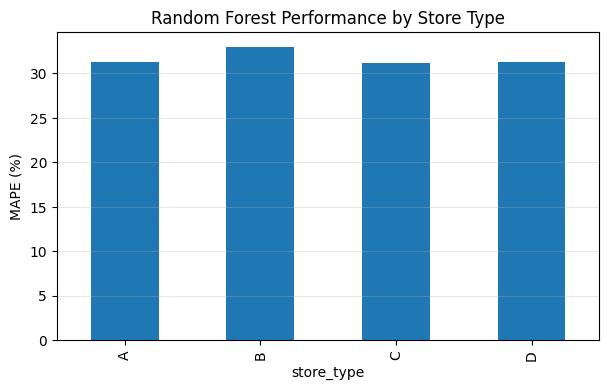

In [11]:
# Save validation results
valid_result = valid_df.copy()

valid_result["prediction"] = y_pred

valid_result["abs_error"] = np.abs(
    valid_result["sales"] -
    valid_result["prediction"]
)

valid_result["ape"] = (
    np.abs(
        valid_result["sales"] -
        valid_result["prediction"]
    )
    /
    valid_result["sales"]
) * 100

valid_result = valid_result[
    valid_result["sales"] != 0
]

valid_result["store_type"] = np.select(
    [
        valid_result["store_type_a"] == 1,
        valid_result["store_type_b"] == 1,
        valid_result["store_type_c"] == 1,
        valid_result["store_type_d"] == 1,
    ],

    [
        "A",
        "B",
        "C",
        "D"
    ]

)

rf_storetype = (
    valid_result
    .groupby("store_type")
    .agg(
        MAE=("abs_error","mean"),
        MAPE=("ape","mean"),
        Stores=("store_id","nunique")
    )

)

print(rf_storetype)

plt.figure(figsize=(7,4))

rf_storetype["MAPE"].plot(
    kind="bar"
)

plt.ylabel("MAPE (%)")

plt.title("Random Forest Performance by Store Type")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [12]:
# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(y_valid, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_valid, y_pred)
)

mape = (
    np.abs((y_valid - y_pred) / y_valid)
)

mape = mape[y_valid != 0].mean() * 100

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

RANDOM FOREST PERFORMANCE
MAE  : 2602.70
RMSE : 3512.78
MAPE : 31.31%


ERROR SUMMARY
          abs_error           ape
count  23680.000000  23680.000000
mean    2134.221318     31.307518
std     2243.873567     29.859930
min        0.076744      0.001070
25%      717.760983     12.031250
50%     1545.373078     25.221220
75%     2718.972382     41.964313
max    32857.073119    783.799331


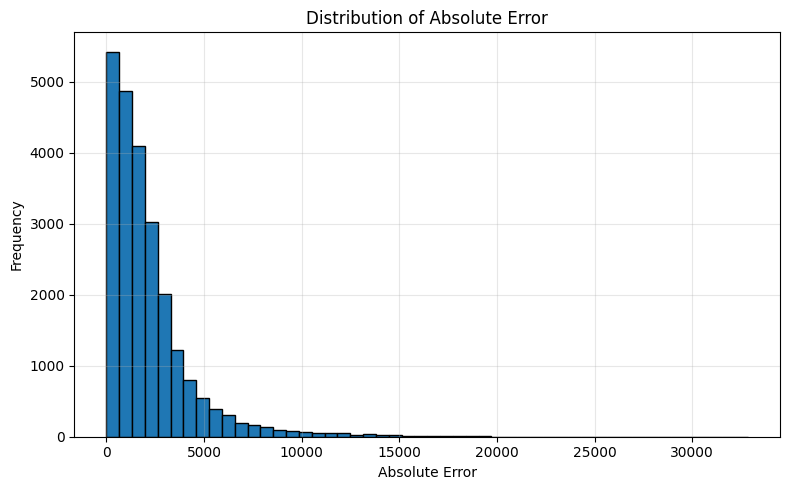

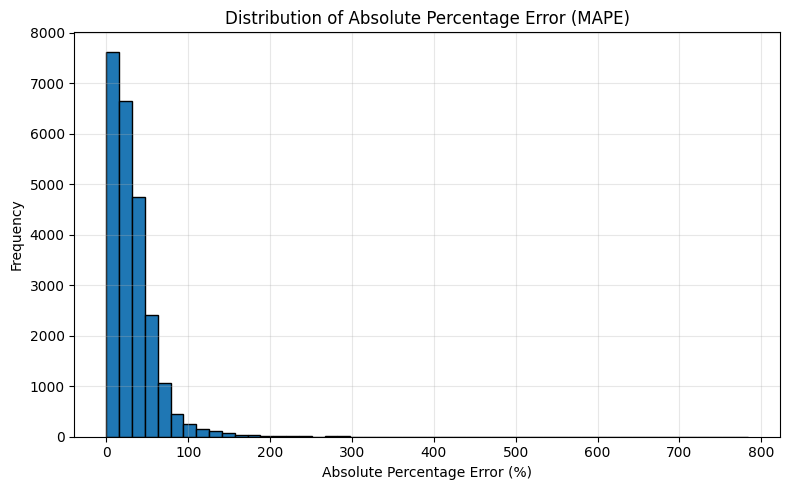

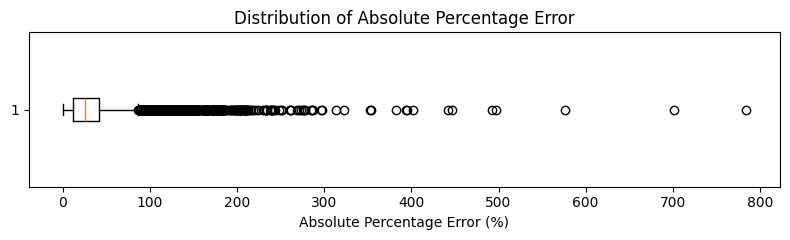

MEAN VS MEDIAN ERROR
Mean Absolute Error : 2134.22
Median Absolute Error : 1545.37
Mean MAPE : 31.31%
Median MAPE : 25.22%


In [18]:
# ==========================================================
# Error Analysis
# ==========================================================
# Analyse the distribution of forecasting errors on the
# validation set.
# ==========================================================

import matplotlib.pyplot as plt

# ==========================================================
# Error Summary Statistics
# ==========================================================

print("=" * 60)
print("ERROR SUMMARY")
print("=" * 60)

print(
    valid_result[
        [
            "abs_error",
            "ape"
        ]
    ].describe()
)

# ==========================================================
# Absolute Error Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(

    valid_result["abs_error"],

    bins=50,

    edgecolor="black"

)

plt.title(
    "Distribution of Absolute Error"
)

plt.xlabel(
    "Absolute Error"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Absolute Percentage Error Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(

    valid_result["ape"],

    bins=50,

    edgecolor="black"

)

plt.title(
    "Distribution of Absolute Percentage Error (MAPE)"
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Frequency"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ==========================================================
# Boxplot of Percentage Error
# ==========================================================

plt.figure(figsize=(8, 2.5))

plt.boxplot(

    valid_result["ape"],

    vert=False

)

plt.title(
    "Distribution of Absolute Percentage Error"
)

plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.tight_layout()

plt.show()

# ==========================================================
# Mean vs Median Error
# ==========================================================

print("=" * 60)
print("MEAN VS MEDIAN ERROR")
print("=" * 60)

print(

    f"Mean Absolute Error : "

    f"{valid_result['abs_error'].mean():.2f}"

)

print(

    f"Median Absolute Error : "

    f"{valid_result['abs_error'].median():.2f}"

)

print(

    f"Mean MAPE : "

    f"{valid_result['ape'].mean():.2f}%"

)

print(

    f"Median MAPE : "

    f"{valid_result['ape'].median():.2f}%"

)

ERROR BY PROMOTION
       Observations          MAE   Median_MAE       MAPE  Median_MAPE
promo                                                                
0             15229  2148.668098  1547.216082  31.466586    25.222181
1              8451  2108.187711  1542.700748  31.020874    25.204849


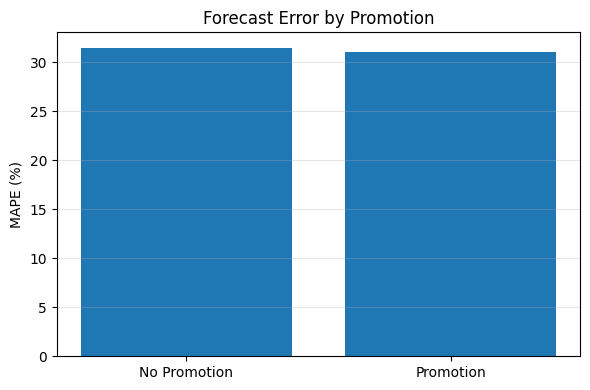

<Figure size 600x500 with 0 Axes>

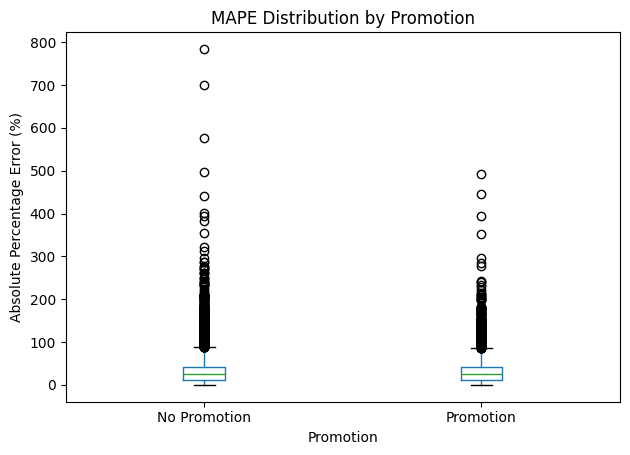

In [19]:
# ==========================================================
# Error Analysis by Promotion
# ==========================================================

promo_error = (

    valid_result

    .groupby("promo")

    .agg(

        Observations=("promo", "count"),

        MAE=("abs_error", "mean"),

        Median_MAE=("abs_error", "median"),

        MAPE=("ape", "mean"),

        Median_MAPE=("ape", "median")

    )

)

print("=" * 60)
print("ERROR BY PROMOTION")
print("=" * 60)

print(promo_error)

plt.figure(figsize=(6, 4))

plt.bar(

    ["No Promotion", "Promotion"],

    promo_error["MAPE"]

)

plt.ylabel("MAPE (%)")

plt.title("Forecast Error by Promotion")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

plt.figure(figsize=(6, 5))

valid_result.boxplot(

    column="ape",

    by="promo",

    grid=False

)

plt.suptitle("")

plt.title("MAPE Distribution by Promotion")

plt.xlabel("Promotion")

plt.ylabel("Absolute Percentage Error (%)")

plt.xticks([1, 2], ["No Promotion", "Promotion"])

plt.tight_layout()

plt.show()

ERROR BY SALES LEVEL
             Observations    Mean_Sales          MAE       MAPE  Median_MAPE
sales_level                                                                 
Low                  5920   3865.482770  1868.956407  55.102877    45.114918
Medium               5922   5609.148430   725.982825  13.153005    10.580869
High                 5918   7237.927847  1271.458183  17.224202    16.201377
Very High            5920  10979.380236  4670.672139  39.751365    38.737113


C:\Users\setue\AppData\Local\Temp\ipykernel_26384\780559754.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sales_level")


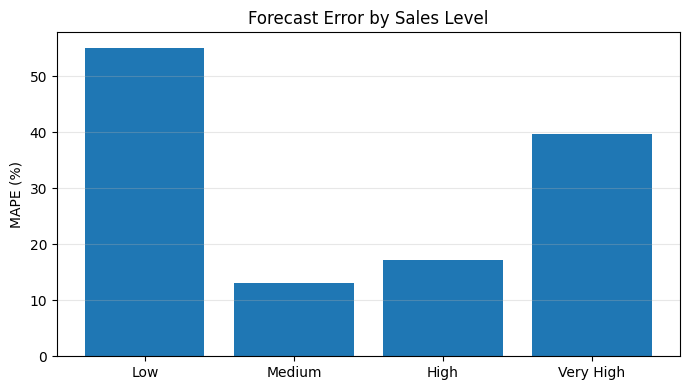

<Figure size 800x500 with 0 Axes>

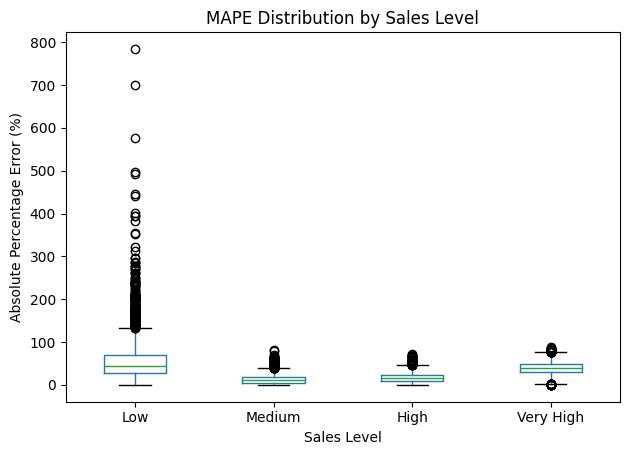

In [20]:
# ==========================================================
# Error Analysis by Sales Level
# ==========================================================

valid_result["sales_level"] = pd.qcut(

    valid_result["sales"],

    q=4,

    labels=[

        "Low",

        "Medium",

        "High",

        "Very High"

    ]

)

sales_error = (

    valid_result

    .groupby("sales_level")

    .agg(

        Observations=("sales","count"),

        Mean_Sales=("sales","mean"),

        MAE=("abs_error","mean"),

        MAPE=("ape","mean"),

        Median_MAPE=("ape","median")

    )

)

print("=" * 60)
print("ERROR BY SALES LEVEL")
print("=" * 60)

print(sales_error)

plt.figure(figsize=(7, 4))

plt.bar(

    sales_error.index,

    sales_error["MAPE"]

)

plt.ylabel("MAPE (%)")

plt.title("Forecast Error by Sales Level")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

plt.figure(figsize=(8, 5))

valid_result.boxplot(

    column="ape",

    by="sales_level",

    grid=False

)

plt.suptitle("")

plt.title("MAPE Distribution by Sales Level")

plt.xlabel("Sales Level")

plt.ylabel("Absolute Percentage Error (%)")

plt.tight_layout()

plt.show()

TOP 50 LARGEST PREDICTION ERRORS


,store_id,date,sales,prediction,abs_error,ape,promo,school_holiday,open
610749,85,2015-07-05,632,5585.611771,4953.611771,783.799331,0,0,0
582108,666,2015-07-08,591,4734.494571,4143.494571,701.098912,0,0,1
599646,74,2015-06-20,866,5857.354323,4991.354323,576.368860,0,0,1
616298,90,2015-07-10,1146,6839.714035,5693.714035,496.833685,0,1,1
24928,122,2015-06-30,1156,6855.328305,5699.328305,493.021480,1,1,1
337240,427,2015-06-30,1148,6270.736983,5122.736983,446.231445,1,1,1
600578,75,2015-06-28,1196,6480.500006,5284.500006,441.847827,0,0,0
613494,88,2015-06-08,1276,6404.027516,5128.027516,401.883034,0,0,1
600558,75,2015-06-08,1092,5407.849462,4315.849462,395.224310,0,0,1
493396,58,2015-06-30,1281,6319.705709,5038.705709,393.341585,1,1,1


PROMOTION DISTRIBUTION
promo
0    36
1    14
Name: count, dtype: int64
SCHOOL HOLIDAY DISTRIBUTION
school_holiday
0    44
1     6
Name: count, dtype: int64
STORE TYPE DISTRIBUTION
store_type
A    27
D    16
C     6
B     1
Name: count, dtype: int64


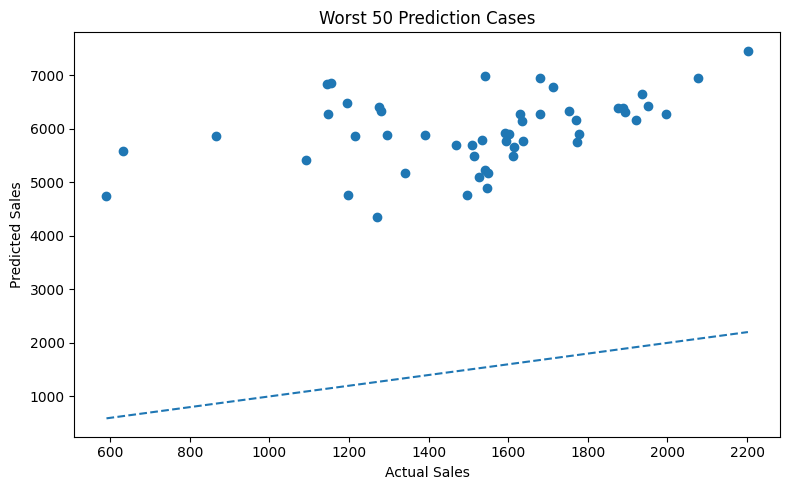

DATE DISTRIBUTION OF WORST 50 CASES
date
2015-06-08    2
2015-06-12    3
2015-06-14    1
2015-06-16    1
2015-06-19    1
2015-06-20    5
2015-06-21    1
2015-06-23    1
2015-06-27    6
2015-06-28    2
2015-06-30    5
2015-07-01    3
2015-07-02    1
2015-07-03    1
2015-07-04    1
2015-07-05    1
2015-07-06    3
2015-07-08    1
2015-07-10    3
2015-07-11    2
2015-07-14    1
2015-07-15    1
2015-07-18    3
2015-07-19    1
Name: count, dtype: int64


In [31]:
# ==========================================================
# Worst Prediction Cases
# ==========================================================

worst_cases = (

    valid_result

    .sort_values(

        "ape",

        ascending=False

    )

    .head(50)

)

print("=" * 60)
print("TOP 50 LARGEST PREDICTION ERRORS")
print("=" * 60)

display(

    worst_cases[

        [

            "store_id",

            "date",

            "sales",

            "prediction",

            "abs_error",

            "ape",

            "promo",

            "school_holiday",

            "open"

        ]

    ]

)
print("=" * 60)
print("PROMOTION DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["promo"]
    .value_counts()
)

print("=" * 60)
print("SCHOOL HOLIDAY DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["school_holiday"]
    .value_counts()
)

####
print("=" * 60)
print("STORE TYPE DISTRIBUTION")
print("=" * 60)

print(
    worst_cases["store_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.scatter(

    worst_cases["sales"],

    worst_cases["prediction"]

)

plt.plot(

    [

        worst_cases["sales"].min(),

        worst_cases["sales"].max()

    ],

    [

        worst_cases["sales"].min(),

        worst_cases["sales"].max()

    ],

    linestyle="--"

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Worst 50 Prediction Cases")

plt.tight_layout()

plt.show()

print("=" * 60)
print("DATE DISTRIBUTION OF WORST 50 CASES")
print("=" * 60)

print(
    worst_cases["date"]
    .value_counts()
    .sort_index()
)

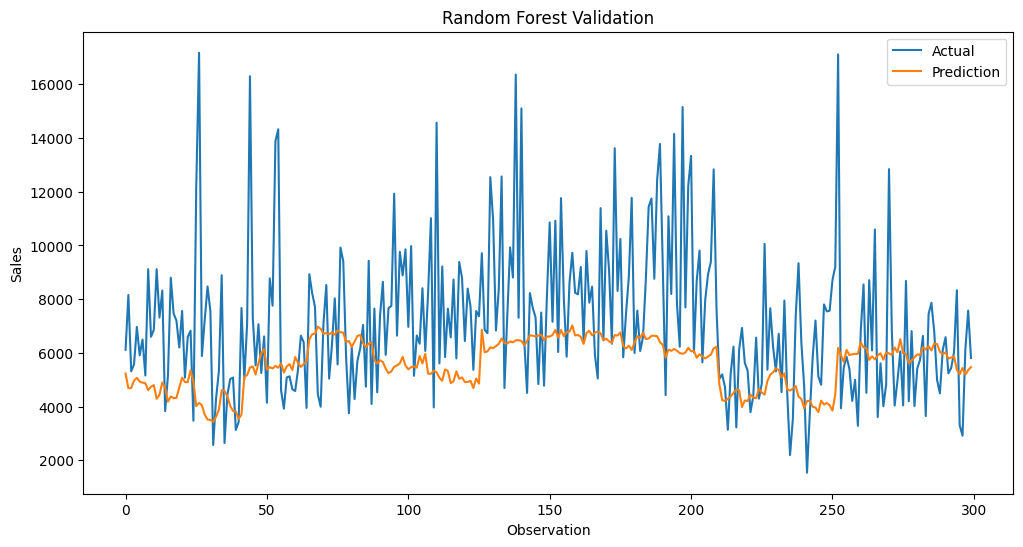

In [33]:
# ==========================================================
# Prediction vs Actual
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_valid.values[:300],
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Prediction"
)

plt.legend()

plt.title("Random Forest Validation")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.show()

In [34]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",
    ascending=False

).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance)

FEATURE IMPORTANCE
                 Feature  Importance
0                   open         0.0
1       rolling_median_7         0.0
2      rolling_median_21         0.0
3      rolling_median_28         0.0
4          rolling_max_7         0.0
5          rolling_min_7         0.0
6         rolling_max_14         0.0
7         rolling_min_14         0.0
8         rolling_max_21         0.0
9         rolling_min_21         0.0
10        rolling_max_28         0.0
11        rolling_min_28         0.0
12          promo_mean_7         0.0
13         promo_mean_14         0.0
14         promo_weekend         0.0
15   promo_schoolholiday         0.0
16    promo_stateholiday         0.0
17          store_type_a         0.0
18          store_type_b         0.0
19          store_type_c         0.0
20          store_type_d         0.0
21          assortment_a         0.0
22          assortment_b         0.0
23          assortment_c         0.0
24       state_holiday_0         0.0
25       state_holi

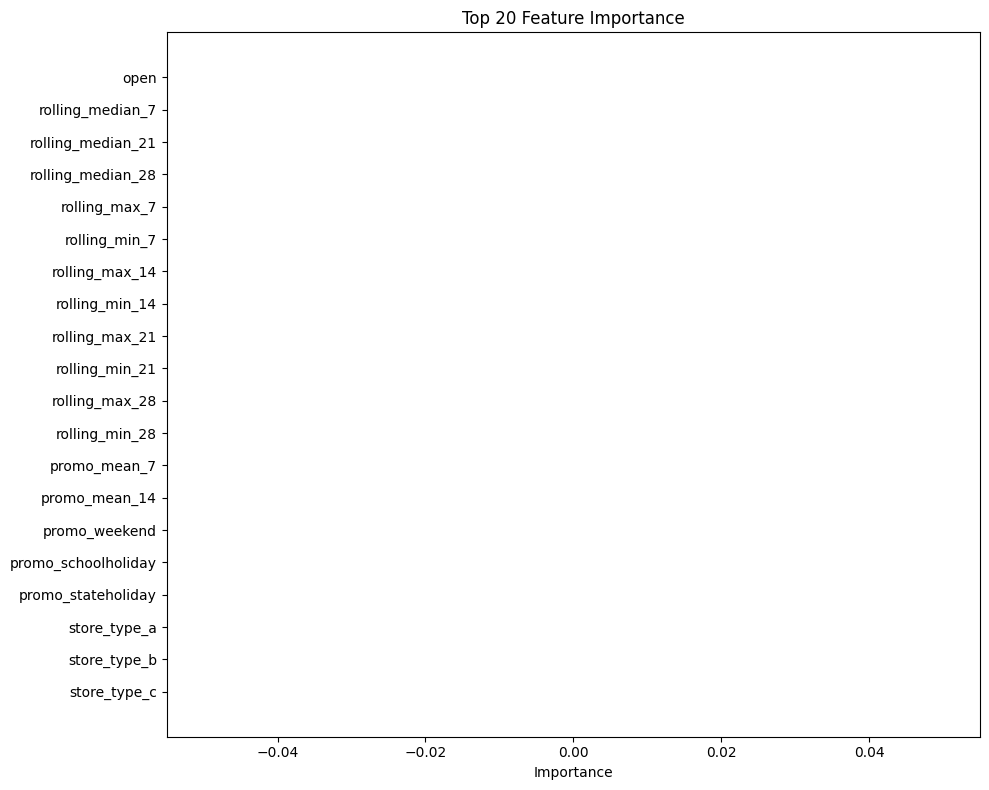

In [35]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]

)

plt.title("Top 20 Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [36]:
print(X_train.columns.tolist())

['open', 'promo', 'school_holiday', 'competition_distance', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'promo_lag_1', 'promo_lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_28', 'rolling_std_28', 'rolling_median_7', 'rolling_median_14', 'rolling_median_21', 'rolling_median_28', 'rolling_max_7', 'rolling_min_7', 'rolling_max_14', 'rolling_min_14', 'rolling_max_21', 'rolling_min_21', 'rolling_max_28', 'rolling_min_28', 'promo_mean_7', 'promo_mean_14', 'promo_weekend', 'promo_schoolholiday', 'promo_stateholiday', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']


In [37]:
# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

print("=" * 60)
print("HYPERPARAMETER TUNING WITH ROLLING CV")
print("=" * 60)

parameter_list = [

    {
        "n_estimators": 200,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 5
    }

]

# Rolling CV settings
n_folds = 3
forecast_horizon = 42

all_dates = np.sort(train_df["date"].unique())

results = []

best_mape = np.inf
best_params = None

for i, params in enumerate(parameter_list, start=1):

    print(f"\nEvaluating Model {i}/{len(parameter_list)}")

    fold_mae = []
    fold_rmse = []
    fold_mape = []

    for fold in range(n_folds):
        valid_end = len(all_dates) - fold * forecast_horizon
        valid_start = valid_end - forecast_horizon

        valid_dates = all_dates[valid_start:valid_end]
        train_dates = all_dates[:valid_start]

        train_fold = train_df[
            train_df["date"].isin(train_dates)
        ].copy()

        valid_fold = train_df[
            train_df["date"].isin(valid_dates)
        ].copy()

        X_tr = train_fold.drop(columns=drop_columns)
        y_tr = train_fold[target]

        X_va = valid_fold.drop(columns=drop_columns)
        y_va = valid_fold[target]

        rf = RandomForestRegressor(

            random_state=42,
            n_jobs=-1,
            **params

        )

        rf.fit(X_tr, y_tr)

        pred = rf.predict(X_va)

        mae = mean_absolute_error(
            y_va,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_va,
                pred
            )
        )

        mask = y_va != 0

        mape = (
                np.abs(
                    (
                            y_va[mask] - pred[mask]
                    )
                    /
                    y_va[mask]
                ).mean()
                * 100
        )

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_mape.append(mape)

    avg_mae = np.mean(fold_mae)
    avg_rmse = np.mean(fold_rmse)
    avg_mape = np.mean(fold_mape)

    results.append({

        "n_estimators": params["n_estimators"],
        "max_features": params["max_features"],
        "min_samples_leaf": params["min_samples_leaf"],
        "CV_MAE": avg_mae,
        "CV_RMSE": avg_rmse,
        "CV_MAPE": avg_mape

    })

    if avg_mape < best_mape:
        best_mape = avg_mape
        best_params = params

results = (
    pd.DataFrame(results)
    .sort_values("CV_MAPE")
    .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("TUNING RESULTS")
print("=" * 60)

print(results)

print("\nBest Parameters")
print(best_params)

print(f"\nBest CV MAPE : {best_mape:.2f}%")

HYPERPARAMETER TUNING WITH ROLLING CV

Evaluating Model 1/4

Evaluating Model 2/4

Evaluating Model 3/4

Evaluating Model 4/4


TUNING RESULTS
   n_estimators max_features  min_samples_leaf       CV_MAE      CV_RMSE  \
0           500         sqrt                10  2651.934627  3547.185605   
1           300         sqrt                10  2652.663373  3548.273127   
2           200         sqrt                10  2652.501397  3548.581952   
3           300         sqrt                 5  2639.922408  3530.400923   

     CV_MAPE  
0  31.464905  
1  31.487314  
2  31.489932  
3  31.576795  

Best Parameters
{'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 10}

Best CV MAPE : 31.46%


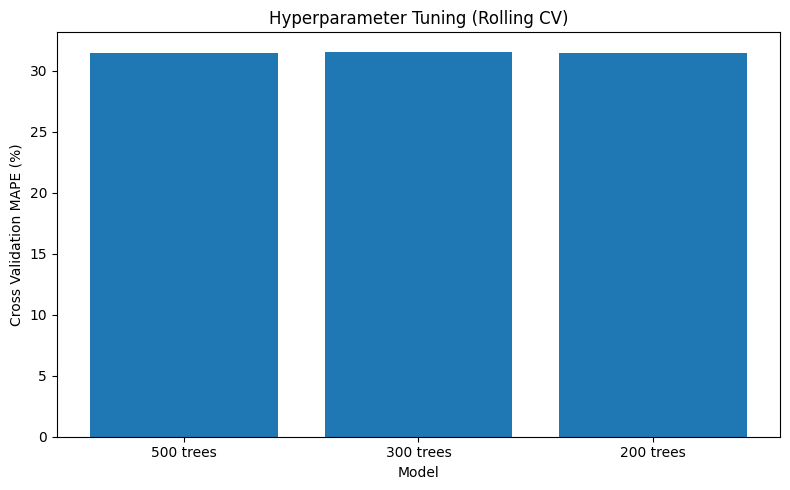

In [38]:
plt.figure(figsize=(8,5))

labels = (
    results["n_estimators"].astype(str)
    + " trees"
)

plt.bar(
    labels,
    results["CV_MAPE"]
)

plt.title("Hyperparameter Tuning (Rolling CV)")

plt.xlabel("Model")

plt.ylabel("Cross Validation MAPE (%)")

plt.tight_layout()

plt.show()

In [39]:
# ==========================================================
# Train Final Random Forest on Full Historical Data
# ==========================================================

print("=" * 60)
print("TRAIN FINAL RANDOM FOREST")
print("=" * 60)

# Use all available historical data
full_df = sales_fe.dropna().copy()

X_full = full_df.drop(columns=drop_columns)
y_full = full_df[target]

# Train final model
final_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_full, y_full)

print("Final model training completed.")

print(f"Training observations : {len(full_df):,}")
print(f"Number of features    : {X_full.shape[1]}")

TRAIN FINAL RANDOM FOREST
Final model training completed.
Training observations : 605,696
Number of features    : 57


In [51]:
from sklearn.inspection import permutation_importance

# ==========================================================
# Permutation Feature Importance
# ==========================================================

perm_importance = permutation_importance(
    final_rf,
    X_valid,
    y_valid,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

perm_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(perm_df.head(20))

                 Feature  Importance
0   competition_distance  588.982546
1         rolling_max_28  339.409324
2      rolling_median_28  301.606465
3        rolling_mean_28  301.348780
4         rolling_max_21  280.826820
5         rolling_max_14  246.897779
6           store_type_d  217.541235
7      rolling_median_21  217.426764
8         rolling_std_28  212.623406
9           store_type_a  211.588785
10     rolling_median_14  209.969770
11       rolling_mean_14  199.138356
12       rolling_mean_21  192.783843
13          assortment_a  188.010639
14          assortment_c  179.261743
15        rolling_std_14  152.544187
16        rolling_std_21  149.087507
17         rolling_max_7  114.785978
18      rolling_median_7  103.100456
19        rolling_mean_7   94.655399


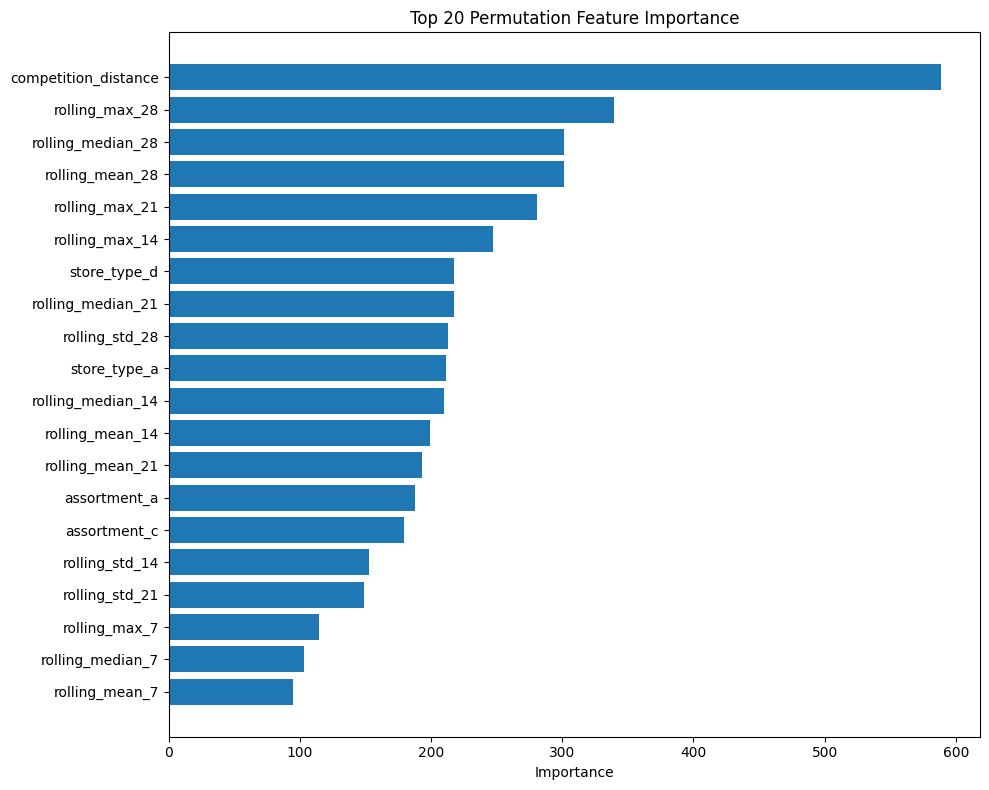

In [52]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["Feature"][:20][::-1],
    perm_df["Importance"][:20][::-1]
)

plt.title("Top 20 Permutation Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [53]:
print(future_fe.columns.tolist())

['store_id', 'date', 'sales', 'customers', 'open', 'promo', 'school_holiday', 'competition_distance', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'promo_lag_1', 'promo_lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_28', 'rolling_std_28', 'rolling_median_7', 'rolling_median_14', 'rolling_median_21', 'rolling_median_28', 'rolling_max_7', 'rolling_min_7', 'rolling_max_14', 'rolling_min_14', 'rolling_max_21', 'rolling_min_21', 'rolling_max_28', 'rolling_min_28', 'promo_mean_7', 'promo_mean_14', 'promo_weekend', 'promo_schoolholiday', 'promo_stateholiday', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']


In [41]:
# ==========================================================
# Prepare Future Features
# ==========================================================

future_X = future_fe.drop(
    columns=drop_columns
)

print("=" * 60)
print("CHECK FUTURE FEATURES")
print("=" * 60)

print("Training shape :", X_full.shape)
print("Future shape   :", future_X.shape)

print("\nFeature names identical:")
print(X_full.columns.equals(future_X.columns))

CHECK FUTURE FEATURES
Training shape : (605696, 57)
Future shape   : (40560, 57)

Feature names identical:
True


In [42]:
# ==========================================================
# Predict Future Sales
# ==========================================================

future_pred = final_rf.predict(future_X)

future_result = future_fe.copy()

future_result["sales_prediction"] = future_pred

print("=" * 60)
print("FUTURE PREDICTION")
print("=" * 60)

print(future_result[
          [
              "store_id",
              "date",
              "sales_prediction"
          ]
      ].head())

print("\nPrediction Summary")

print(future_result["sales_prediction"].describe())

FUTURE PREDICTION
   store_id       date  sales_prediction
0         1 2015-09-17       3823.649494
1         2 2015-09-17       6868.385142
2         3 2015-09-17       6457.089102
3         4 2015-09-17       6545.103063
4         5 2015-09-17       6758.129058

Prediction Summary
count    40560.000000
mean      5795.178551
std       1269.204964
min       1096.510652
25%       5245.737544
50%       5919.494439
75%       6524.389595
max      11085.068589
Name: sales_prediction, dtype: float64


In [43]:
# ==========================================================
# Save Prediction
# ==========================================================

future_result.to_csv(
    processed_dir / "future_prediction_rf.csv",
    index=False
)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [44]:

#Weekly  Aggregation
# ==========================================================
# Create Forecast Week
# ==========================================================

future_result = future_result.sort_values(
    ["date", "store_id"]
).reset_index(drop=True)

forecast_start = future_result["date"].min()

future_result["forecast_week"] = (
                                         (future_result["date"] - forecast_start).dt.days // 7
                                 ) + 1

print("=" * 60)
print("FORECAST WEEKS")
print("=" * 60)

print(future_result["forecast_week"].value_counts().sort_index())

FORECAST WEEKS
forecast_week
1    4732
2    4732
3    4732
4    4732
5    4732
6    4732
7    4732
8    4732
9    2704
Name: count, dtype: int64


In [45]:
# ==========================================================
# Weekly Forecast by Store
# ==========================================================

store_weekly = (
    future_result
    .groupby(
        ["store_id", "forecast_week"],
        as_index=False
    )["sales_prediction"]
    .sum()
)

print("=" * 60)
print("STORE WEEKLY FORECAST")
print("=" * 60)

print(store_weekly.head())

store_weekly.to_csv(
    processed_dir / "store_weekly_forecast.csv",
    index=False
)

STORE WEEKLY FORECAST
   store_id  forecast_week  sales_prediction
0         1              1      28776.566581
1         1              2      27982.719918
2         1              3      27541.317791
3         1              4      27181.762569
4         1              5      26943.558608


In [46]:
# ==========================================================
# Recover Store Type
# ==========================================================

future_result["store_type"] = np.select(
    [
        future_result["store_type_a"] == 1,
        future_result["store_type_b"] == 1,
        future_result["store_type_c"] == 1,
        future_result["store_type_d"] == 1
    ],
    [
        "A",
        "B",
        "C",
        "D"
    ]
)

In [47]:
# ==========================================================
# Weekly Forecast by Store Type
# ==========================================================

storetype_weekly = (
    future_result
    .groupby(
        ["store_type", "forecast_week"],
        as_index=False
    )["sales_prediction"]
    .sum()
)

print(storetype_weekly)

storetype_weekly.to_csv(
    processed_dir / "storetype_weekly_forecast.csv",
    index=False
)

   store_type  forecast_week  sales_prediction
0           A              1      1.520822e+07
1           A              2      1.522312e+07
2           A              3      1.522598e+07
3           A              4      1.523708e+07
4           A              5      1.524310e+07
5           A              6      1.525282e+07
6           A              7      1.525876e+07
7           A              8      1.524103e+07
8           A              9      8.704337e+06
9           B              1      3.943168e+05
10          B              2      3.966403e+05
11          B              3      3.948492e+05
12          B              4      3.931344e+05
13          B              5      3.940125e+05
14          B              6      3.950076e+05
15          B              7      3.938558e+05
16          B              8      3.918862e+05
17          B              9      2.238045e+05
18          C              1      3.054202e+06
19          C              2      3.054274e+06
20          C

In [48]:
# ==========================================================
# Weekly Forecast for Company
# ==========================================================

company_weekly = (
    future_result
    .groupby(
        "forecast_week",
        as_index=False
    )["sales_prediction"]
    .sum()
)

print(company_weekly)

company_weekly.to_csv(
    processed_dir / "company_weekly_forecast.csv",
    index=False
)

   forecast_week  sales_prediction
0              1      2.739606e+07
1              2      2.742478e+07
2              3      2.742508e+07
3              4      2.742607e+07
4              5      2.743272e+07
5              6      2.744830e+07
6              7      2.744777e+07
7              8      2.741402e+07
8              9      1.563764e+07


In [49]:
# ==========================================================
# Total Forecast over Next 6 Weeks
# ==========================================================

total_sales = future_result["sales_prediction"].sum()

print("=" * 60)
print("TOTAL SALES OVER NEXT 6 WEEKS")
print("=" * 60)

print(f"{total_sales:,.2f}")

TOTAL SALES OVER NEXT 6 WEEKS
235,052,442.03
